In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
#Karol Wilczyński, pd3985 - wybrane miasto Waszyngton, USA
df = pd.read_csv("https://data.insideairbnb.com/united-states/dc/washington-dc/2024-09-17/data/listings.csv.gz")
pd.set_option('display.max_columns', None)

In [ ]:
print('=== Informacje o zbiorze danych ===')
print(f'Liczba wierszy: {df.shape[0]}')
print(f'Liczba kolumn: {df.shape[1]}')
df.info()

=== Informacje o zbiorze danych ===
Liczba wierszy: 5454
Liczba kolumn: 75
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5454 entries, 0 to 5453
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5454 non-null   int64  
 1   listing_url                                   5454 non-null   object 
 2   scrape_id                                     5454 non-null   int64  
 3   last_scraped                                  5454 non-null   object 
 4   source                                        5454 non-null   object 
 5   name                                          5454 non-null   object 
 6   description                                   5365 non-null   object 
 7   neighborhood_overview                         3716 non-null   object 
 8   picture_url                                   5454 non-null   o

In [ ]:
print('\n=== Pierwsze kilka wierszy ===')
print(df.head())
print('\n=== Losowe kilka wierszy ===')
print(df.sample(5))
print('\n=== Ostatnie kilka wierszy ===')
print(df.tail())


=== Pierwsze kilka wierszy ===
     id                        listing_url       scrape_id last_scraped  \
0  3686  https://www.airbnb.com/rooms/3686  20240917031308   2024-09-17   
1  3943  https://www.airbnb.com/rooms/3943  20240917031308   2024-09-17   
2  4197  https://www.airbnb.com/rooms/4197  20240917031308   2024-09-17   
3  4529  https://www.airbnb.com/rooms/4529  20240917031308   2024-09-17   
4  5589  https://www.airbnb.com/rooms/5589  20240917031308   2024-09-17   

            source                                name  \
0      city scrape                     Vita's Hideaway   
1      city scrape    Historic Rowhouse Near Monuments   
2      city scrape  Capitol Hill Bedroom walk to Metro   
3  previous scrape           Bertina's  House Part One   
4      city scrape            Cozy apt in Adams Morgan   

                                         description  \
0  IMPORTANT NOTES<br />* Carefully read and be s...   
1  You will be staying in high ceiling  bedroom w...   


In [ ]:
# Podstawowe statystyki numeryczne
print('\n=== Podstawowe statystyki numeryczne ===')
print(df.describe())


=== Podstawowe statystyki numeryczne ===
                 id     scrape_id       host_id  host_listings_count  \
count  5.454000e+03  5.454000e+03  5.454000e+03          5454.000000   
mean   5.011144e+17  2.024092e+13  1.576660e+08           264.657132   
std    5.008290e+17  2.695560e+00  1.818360e+08           936.019605   
min    3.686000e+03  2.024092e+13  4.492000e+03             1.000000   
25%    3.235964e+07  2.024092e+13  1.980346e+07             1.000000   
50%    5.905722e+17  2.024092e+13  6.827528e+07             3.000000   
75%    1.010001e+18  2.024092e+13  2.703844e+08            21.000000   
max    1.247019e+18  2.024092e+13  6.511042e+08          4495.000000   

       host_total_listings_count  neighbourhood_group_cleansed     latitude  \
count                5454.000000                           0.0  5454.000000   
mean                  364.254309                           NaN    38.909739   
std                  1137.880287                           NaN     0.025

In [ ]:
# Podstawowe statystyki dla zmiennych kategorycznych
print('\n=== Unikalne wartości w zmiennych kategorycznych ===')
categorical_columns = df.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f'\nKolumna: {col}')
    print(df[col].value_counts().head())


=== Unikalne wartości w zmiennych kategorycznych ===

Kolumna: listing_url
listing_url
https://www.airbnb.com/rooms/3686                  1
https://www.airbnb.com/rooms/897724301225833686    1
https://www.airbnb.com/rooms/899223983391286961    1
https://www.airbnb.com/rooms/899143891104718058    1
https://www.airbnb.com/rooms/898525224636714733    1
Name: count, dtype: int64

Kolumna: last_scraped
last_scraped
2024-09-17    5454
Name: count, dtype: int64

Kolumna: source
source
city scrape        4522
previous scrape     932
Name: count, dtype: int64

Kolumna: name
name
Upscale and Great Location                  16
Sojourn on 17th | Pets Welcome               8
Sojourn the 13th Street Flats                7
Contemporary | Downtown | Views | Luxury     7
Sojourn on 15th                              6
Name: count, dtype: int64

Kolumna: description
description
In Central DC’s NoMa neighborhood, this new city-center building offers luxurious amenities and a sunny, modern living space. I

In [ ]:
from IPython.display import display, HTML

print('\n=== Braki danych ===')
missing_data = df.isnull().sum()
missing_data_html = missing_data.to_frame().to_html()
display(HTML(missing_data_html))

missing_percent = df.isnull().mean() * 100
print('\n=== Braki danych w procentach ===')
print(missing_percent[missing_percent > 0])


=== Braki danych ===


,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
name,0
description,89
neighborhood_overview,1738
picture_url,0
host_id,0



=== Braki danych w procentach ===
description                       1.631830
neighborhood_overview            31.866520
host_location                    19.691969
host_about                       34.781812
host_response_time                5.793913
host_response_rate                5.793913
host_acceptance_rate              4.143748
host_is_superhost                 2.915292
host_neighbourhood                3.208654
neighbourhood                    31.866520
neighbourhood_group_cleansed    100.000000
bathrooms                        17.106711
bathrooms_text                    0.091676
bedrooms                          1.815182
beds                             17.546755
price                            17.088376
calendar_updated                100.000000
has_availability                  0.220022
first_review                     16.134947
last_review                      16.134947
review_scores_rating             16.134947
review_scores_accuracy           16.153282
review_scores_clean

In [ ]:
import time
from tabulate import tabulate

times_dict = {}
start_time = time.time()
for column in df.columns:
    col_type = df[column].dtype

    # Czas obliczania statystyk
    stat_start = time.time()
    if col_type in ['float64', 'int64']:
        df[column].describe()
    else:
        df[column].value_counts()
    stat_time = time.time() - stat_start

    # CZas obliczania grupowań
    group_start = time.time()
    try:
        df.groupby(column).size()
    except Exception:
        pass
    group_time = time.time() - group_start

    times_dict[column] = {'Statystyki': stat_time, 'Grupowanie': group_time}

# Czas obliczania korelacji
corr_start = time.time()
df.select_dtypes(include=['float64', 'int64']).corr()
corr_time = time.time() - corr_start

print("\nPodsumowanie czasów wykonania:")
print("-" * 50)
table = [[column, times['Statystyki'], times['Grupowanie']] for column, times in times_dict.items()]
print(tabulate(table, headers=["Kolumna", "Statystyki (s)", "Grupowanie (s)"], tablefmt="grid"))
print(f"\nCzas obliczania korelacji: {corr_time:.4f}s")


Podsumowanie czasów wykonania:
--------------------------------------------------
+----------------------------------------------+------------------+------------------+
| Kolumna                                      |   Statystyki (s) |   Grupowanie (s) |
+==============================================+==================+==================+
| id                                           |      0.0161724   |      0.0139685   |
+----------------------------------------------+------------------+------------------+
| listing_url                                  |      0.00340104  |      0.0223775   |
+----------------------------------------------+------------------+------------------+
| scrape_id                                    |      0.00973845  |      0.00226283  |
+----------------------------------------------+------------------+------------------+
| last_scraped                                 |      0.000960588 |      0.00383472  |
+----------------------------------------------

In [ ]:
print("Kolumny w DataFrame:")
print(df.columns.tolist())

Kolumny w DataFrame:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availab

In [ ]:
# Kolumny do usunięcia
cols_to_remove = ['neighbourhood_group_cleansed', 'calendar_updated', 'host_about', 'neighborhood_overview']
df.drop(columns=cols_to_remove, inplace=True)
print(f"Usunięto kolumny: {cols_to_remove}")

Usunięto kolumny: ['neighbourhood_group_cleansed', 'calendar_updated', 'host_about', 'neighborhood_overview']


In [ ]:
print(f"Typ danych w kolumnie 'price': {df['price'].dtype}")

print("\nPrzykładowe wartości w kolumnie 'price':")
print(df['price'].head(10))

Typ danych w kolumnie 'price': object

Przykładowe wartości w kolumnie 'price':
0     $67.00
1     $86.00
2    $135.00
3        NaN
4     $60.00
5     $45.00
6     $69.00
7     $85.00
8     $52.00
9    $125.00
Name: price, dtype: object


In [ ]:
# Usunięcie rekordów z brakującymi wartościami w kolumnie 'price'
df = df[df['price'].notnull()]

# Konwersja 'price' na float
df['price'] = df['price'].str.replace('[$,]', '', regex=True).astype(float)

print("=== Sta 'tystyki dla kolumny 'price' (po usunięciu braków danych) ===")
print(df['price'].describe())

price_bins = pd.cut(df['price'], bins=[0, 50, 100, 150, 200, 300, 500, 700])
price_bin_counts = price_bins.value_counts()
print("\n=== Liczba ofert w przedziałach cenowych ===")
print(price_bin_counts)

=== Statystyki dla kolumny 'price' (po usunięciu braków danych) ===
count    4522.000000
mean      181.308050
std       361.399666
min        10.000000
25%        92.000000
50%       130.000000
75%       190.000000
max      7000.000000
Name: price, dtype: float64

=== Liczba ofert w przedziałach cenowych ===
price
(100, 150]    1323
(50, 100]     1210
(150, 200]     757
(200, 300]     554
(300, 500]     304
(0, 50]        241
(500, 700]      86
Name: count, dtype: int64


In [ ]:
# Sprawdzenie mediany dla każdej grupy 'room_type'
print(df.groupby('room_type')['price'].median())

room_type
Entire home/apt    146.0
Hotel room         231.5
Private room        72.0
Shared room         65.0
Name: price, dtype: float64


In [ ]:
type_mapping = {
    'host_since': 'datetime64[ns]',
    'host_response_time': 'category',
    'host_response_rate': float,
    'host_acceptance_rate': float,
    'host_is_superhost': bool,
    'host_identity_verified': bool,
    'neighbourhood_cleansed': 'category',
    'property_type': 'category',
    'room_type': 'category',
    'has_availability': bool,
    'first_review': 'datetime64[ns]',
    'last_review': 'datetime64[ns]',
    'instant_bookable': bool,
}

for column, expected_type in type_mapping.items():
    if column in df.columns:
        current_type = df[column].dtype

        if current_type != expected_type:
            try:
                if expected_type == float:
                    df[column] = pd.to_numeric(df[column].str.replace('[$,%]', '', regex=True), errors='coerce').astype(float)'elif expected_type in ['category', 'datetime64[ns]']:
                    df[column] = df[column].astype(expected_type, errors='ignore')
                elif expected_type == bool:
                    df[column] = df[column].map({'t': True, 'f': False})
                print(f"Zmieniono typ kolumny '{column}' z '{current_type}' na '{expected_type}'")
            except (TypeError, ValueError):
                print(f"Błąd podczas konwersji kolumny '{column}' do typu '{expected_type}'")

Zmieniono typ kolumny 'host_since' z 'object' na 'datetime64[ns]'
Zmieniono typ kolumny 'host_response_time' z 'object' na 'category'
Zmieniono typ kolumny 'host_response_rate' z 'object' na '<class 'float'>'
Zmieniono typ kolumny 'host_acceptance_rate' z 'object' na '<class 'float'>'
Zmieniono typ kolumny 'host_is_superhost' z 'object' na '<class 'bool'>'
Zmieniono typ kolumny 'host_identity_verified' z 'object' na '<class 'bool'>'
Zmieniono typ kolumny 'neighbourhood_cleansed' z 'object' na 'category'
Zmieniono typ kolumny 'property_type' z 'object' na 'category'
Zmieniono typ kolumny 'room_type' z 'object' na 'category'
Zmieniono typ kolumny 'has_availability' z 'object' na '<class 'bool'>'
Zmieniono typ kolumny 'first_review' z 'object' na 'datetime64[ns]'
Zmieniono typ kolumny 'last_review' z 'object' na 'datetime64[ns]'
Zmieniono typ kolumny 'instant_bookable' z 'object' na '<class 'bool'>'


In [ ]:
from collections import Counter
relevant_columns = [
    'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost',
    'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
    'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text',
    'amenities', 'has_availability', 'license'
]

categorical_cols = [col for col in relevant_columns if col in df.columns]

categorical_summary = []

for col in categorical_cols:
    unique_values = df[col].nunique()
    most_frequent = df[col].mode()[0] if not df[col].mode().empty else None
    missing_count = df[col].isnull().sum()

    if col == 'amenities':
        all_amenities = []
        for index in df.index:
            amenities_list = df.loc[index, 'amenities'].strip('{}').replace('"', '').split(',')
            all_amenities.extend(amenities_list)

        amenities_counts = Counter(all_amenities)
        top_amenities = amenities_counts.most_common(3)
        most_frequent = ', '.join([amenity[0] for amenity in top_amenities])

    categorical_summary.append([col, unique_values, most_frequent])

categorical_summary_df = pd.DataFrame(
    categorical_summary,
    columns=['Kolumna', 'Unikalne wartości', 'Najczęstsza wartość']
)

style = """
<style>
.dataframe td {
    word-wrap: break-word;
    max-width: 500px;  /* Zwiększona szerokość */
}
</style>
"""
display(HTML(style))
pd.set_option('display.max_colwidth', None)

display(categorical_summary_df)

,Kolumna,Unikalne wartości,Najczęstsza wartość
0,name,4378,Contemporary | Downtown | Views | Luxury
1,host_name,1576,Sojourn
2,host_location,112,"Washington, DC"
3,host_response_time,4,within an hour
4,host_is_superhost,2,False
5,host_neighbourhood,180,Northwest Washington
6,host_verifications,5,"['email', 'phone']"
7,host_has_profile_pic,2,t
8,neighbourhood_cleansed,39,"Capitol Hill, Lincoln Park"
9,property_type,36,Entire rental unit


In [ ]:
import numpy as np
from scipy import stats

relevant_numeric_columns = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

relevant_categorical_columns = [
    'room_type',
    'neighbourhood_group',
    'neighbourhood',
    'property_type'
]

print("Charakterystyka istotnych zmiennych w zbiorze danych:")
print("-" * 50)

# Analiza zmiennych numerycznych
print("\nZmienne numeryczne:")
print("-" * 30)
numeric_stats = []

for col in relevant_numeric_columns:
    if col in df.columns:
        skewness = stats.skew(df[col].dropna())
        kurtosis = stats.kurtosis(df[col].dropna())

        numeric_stats.append({
            'Zmienna': col,
            'Średnia': df[col].mean(),
            'Mediana': df[col].median(),
            'Odch.Std': df[col].std(),
            'Skośność': skewness,
            'Kurtoza': kurtosis
        })

# Wyświetlenie statystyk dla zmiennych numerycznych
from tabulate import tabulate
print(tabulate(numeric_stats, headers='keys', tablefmt='grid', floatfmt='.3f'))

print("\nZmienne kategoryczne:")
print("-" * 30)
categorical_stats = []

for col in relevant_categorical_columns:
    if col in df.columns:
        n_unique = df[col].nunique()
        most_common = df[col].mode().iloc[0]
        most_common_freq = df[col].value_counts().iloc[0] / len(df) * 100

        categorical_stats.append({
            'Zmienna': col,
            'Liczba unikalnych': n_unique,
            'Najczęstsza wartość': most_common,
            'Wystąpienia najczęstszej (%)': most_common_freq
        })

print(tabulate(categorical_stats, headers='keys', tablefmt='grid', floatfmt='.2f'))

print("\nInterpretacja rozkładów zmiennych numerycznych:")
print("-" * 50)
for stat in numeric_stats:
    print(f"\nZmienna: {stat['Zmienna']}")

# Interpretacja skośności
skew = stat['Skośność']
if abs(skew) < 0.5:
    skew_interpret = "rozkład symetryczny"
elif skew < 0:
    skew_interpret = "rozkład lewostronnie skośny"
else:
    skew_interpret = "rozkład prawostronnie skośny"

# Interpretacja kurtozy
kurt = stat['Kurtoza']
if abs(kurt) < 0.5:
    kurt_interpret = "rozkład mezokurtyczny (normalny)"
elif kurt < 0:
    kurt_interpret = "rozkład platykurtyczny (spłaszczony)"
else:
    kurt_interpret = "rozkład leptokurtyczny (wysmukły)"

print(f"Skośność: {skew:.3f} - {skew_interpret}")
print(f"Kurtoza: {kurt:.3f} - {kurt_interpret}")

Charakterystyka istotnych zmiennych w zbiorze danych:
--------------------------------------------------

Zmienne numeryczne:
------------------------------
+--------------------------------+-----------+-----------+------------+------------+-----------+
| Zmienna                        |   Średnia |   Mediana |   Odch.Std |   Skośność |   Kurtoza |
+================================+===========+===========+============+============+===========+
| price                          |   181.308 |   130.000 |    361.400 |     16.509 |   305.874 |
+--------------------------------+-----------+-----------+------------+------------+-----------+
| minimum_nights                 |    12.446 |     2.000 |     23.367 |      6.788 |    74.626 |
+--------------------------------+-----------+-----------+------------+------------+-----------+
| number_of_reviews              |    75.443 |    28.000 |    113.620 |      2.642 |     9.530 |
+--------------------------------+-----------+-----------+---------

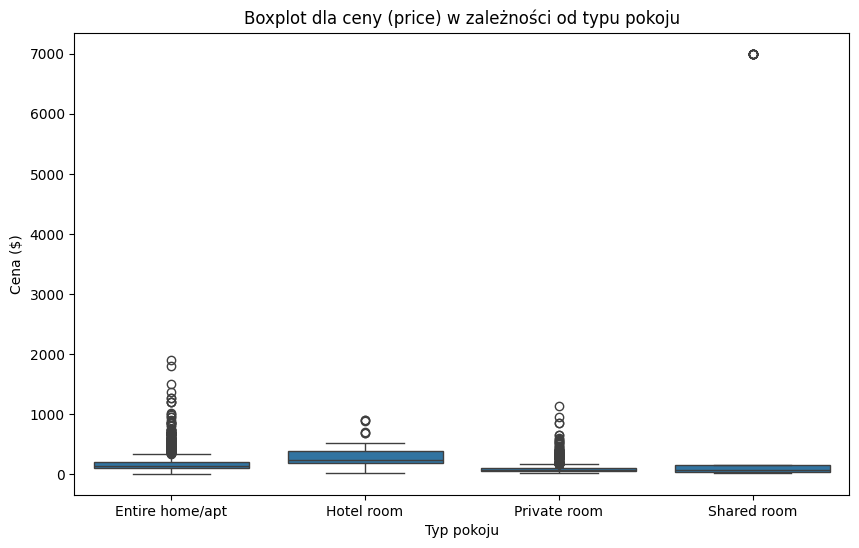

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot dla 'price' w podziale na 'room_type'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='price')
plt.title("Boxplot dla ceny (price) w zależności od typu pokoju")
plt.xlabel("Typ pokoju")
plt.ylabel("Cena ($)")
plt.show()

In [ ]:
price_limits = df['price'].quantile([0.01, 0.99])
df = df[(df['price'] >= price_limits[0.01]) & (df['price'] <= price_limits[0.99])]

In [ ]:
'#czyszczenie danych
numeric_columns_to_clean = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]


def fill_missing_values(df, columns):
    df_clean = df.copy()
    for col in columns:
        if df[col].isnull().sum() > 0:
            if 'review_scores' in col:
                df_clean[col] = df_clean.groupby('room_type')[col].transform(
                    lambda x: x.fillna(x.median())
                )
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    return df_clean

df_cleaned = fill_missing_values(df, numeric_columns_to_clean)

def clean_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound,
                                 np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col]))
    return df_clean

df_cleaned = clean_outliers(df_cleaned, numeric_columns_to_clean)

def normalize_data(df, columns):
    df_normalized = df.copy()
    for col in columns:
        df_normalized[f'{col}_zscore'] = stats.zscore(df[col])
        df_normalized[f'{col}_minmax'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    return df_normalized

df_cleaned = normalize_data(df_cleaned, numeric_columns_to_clean)

In [ ]:
print(df_cleaned.columns)

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90

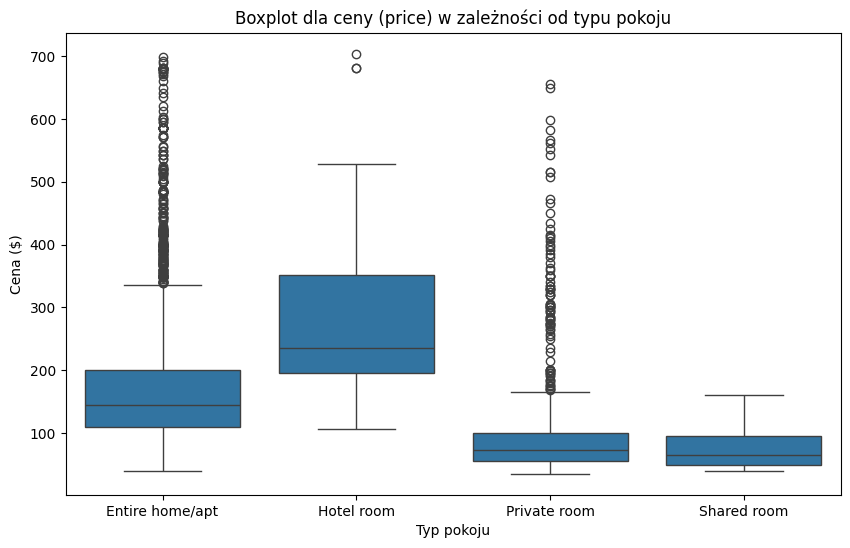

In [ ]:
#boxplot po czysczeniu i ograniczeniu outlierów
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='room_type', y='price')
plt.title("Boxplot dla ceny (price) w zależności od typu pokoju")
plt.xlabel("Typ pokoju")
plt.ylabel("Cena ($)")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='accommodates', y='price', hue='room_type')
plt.title('Wykres Rozrzutu: Cena vs Liczba Gości')
plt.xlabel('Liczba Gości')
plt.ylabel('Cena')
plt.legend(title='Typ Pokoju')
plt.show()

NameError: name 'plt' is not defined

Text(0, 0.5, 'Liczba ofert')

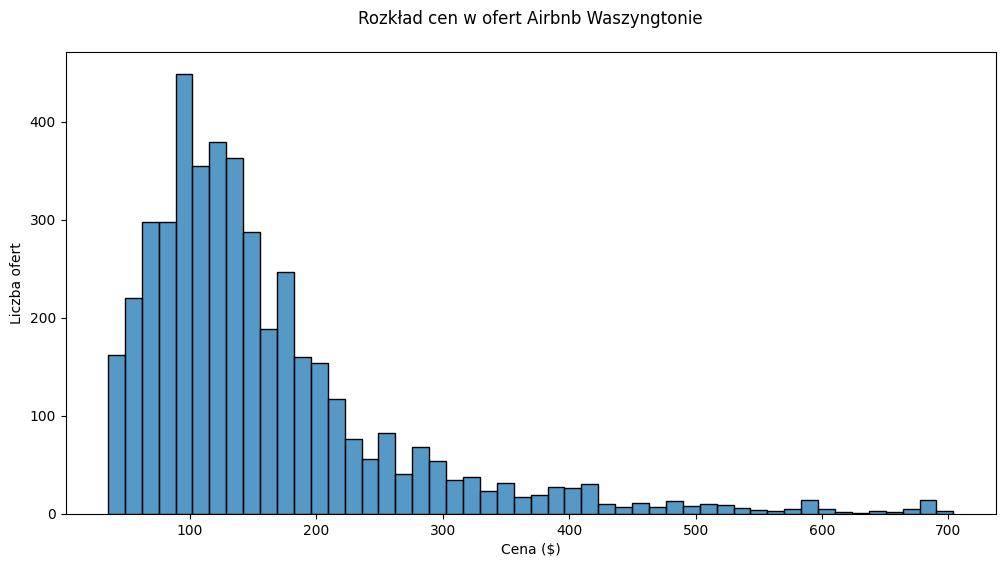

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_cleaned, x='price', bins=50)
plt.title('Rozkład cen w ofert Airbnb Waszyngtonie', pad=20)
plt.xlabel("Cena ($)")
plt.ylabel("Liczba ofert")

Liczba ofert po usunięciu wartości odstających (metoda IQR): 4136


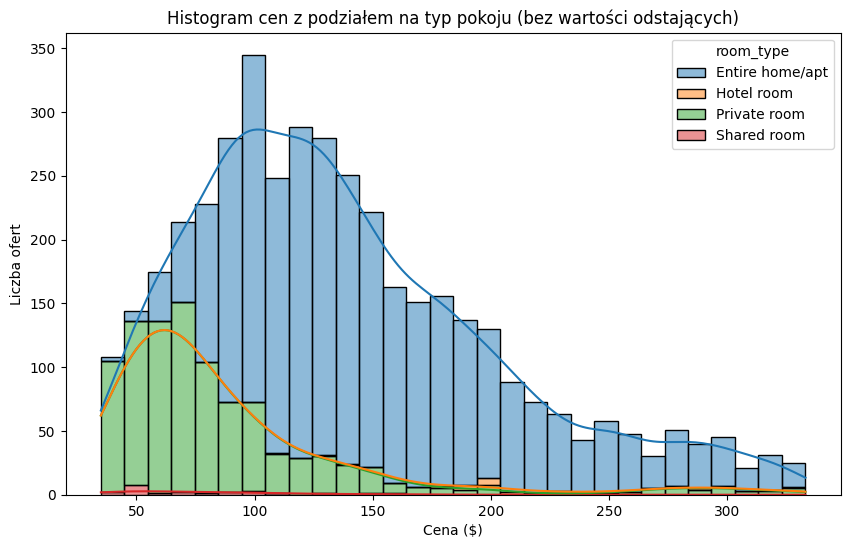

In [ ]:
'# Usuwanie wartości odstających przy użyciu IQR
q1 = df_cleaned['price'].quantile(0.25)
q3 = df_cleaned['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_filtered = df_cleaned[(df_cleaned['price'] >= lower_bound) & (df_cleaned['price'] <= upper_bound)]
print(f"Liczba ofert po usunięciu wartości odstających (metoda IQR): {df_filtered.shape[0]}")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='price', hue='room_type', bins=30, kde=True, multiple='stack')
plt.title("Histogram cen z podziałem na typ pokoju (bez wartości odstających)")
plt.xlabel("Cena ($)")
plt.ylabel("Liczba ofert")
plt.show()

In [ ]:
room_type_analysis = pd.DataFrame({
    'Liczba_ogloszen': df['room_type'].value_counts(),
    'Procent_ogloszen': df['room_type'].value_counts(normalize=True) * 100
})
room_type_analysis['Procent_ogloszen'] = room_type_analysis['Procent_ogloszen'].round(2)
print("Analiza typów pokoi:")
print(room_type_analysis)

price_summary = pd.DataFrame({
    'Metryka': ['Minimum', 'Maksimum', 'Średnia', 'Mediana',
                'Dolny kwartyl', 'Górny kwartyl', 'Odchylenie standardowe',
                'Liczba braków danych'],
    'Wartość': [
        df['price'].min(),
        df['price'].max(),
        df['price'].mean(),
        df['price'].median(),
        df['price'].quantile(0.25),
        df['price'].quantile(0.75),
        df['price'].std(),
        df['price'].isnull().sum()
    ]
})
print("\nStatystyki dla cen:")
print(price_summary)


Analiza typów pokoi:
                 Liczba_ogloszen  Procent_ogloszen
room_type                                         
Entire home/apt             3383             76.18
Private room                 998             22.47
Hotel room                    37              0.83
Shared room                   23              0.52

Statystyki dla cen:
                  Metryka     Wartość
0                 Minimum   35.000000
1                Maksimum  704.000000
2                 Średnia  159.092096
3                 Mediana  130.000000
4           Dolny kwartyl   93.000000
5           Górny kwartyl  189.000000
6  Odchylenie standardowe  105.344620
7    Liczba braków danych    0.000000


In [ ]:
room_type_analysis = pd.DataFrame({
    'Liczba_ogloszen': df_cleaned['room_type'].value_counts(),
    'Procent_ogloszen': df_cleaned['room_type'].value_counts(normalize=True) * 100
})
room_type_analysis['Procent_ogloszen'] = room_type_analysis['Procent_ogloszen'].round(2)
print("Analiza typów pokoi:")
print(room_type_analysis)

price_summary = pd.DataFrame({
    'Metryka': ['Minimum', 'Maksimum', 'Średnia', 'Mediana',
                'Dolny kwartyl', 'Górny kwartyl', 'Odchylenie standardowe',
                'Liczba braków danych'],
    'Wartość': [
        df_cleaned['price'].min(),
        df_cleaned['price'].max(),
        df_cleaned['price'].mean(),
        df_cleaned['price'].median(),
        df_cleaned['price'].quantile(0.25),
        df_cleaned['price'].quantile(0.75),
        df_cleaned['price'].std(),
        df_cleaned['price'].isnull().sum()
    ]
})
print("\nStatystyki dla cen:")
print(price_summary)

Analiza typów pokoi:
                 Liczba_ogloszen  Procent_ogloszen
room_type                                         
Entire home/apt             3383             76.18
Private room                 998             22.47
Hotel room                    37              0.83
Shared room                   23              0.52

Statystyki dla cen:
                  Metryka     Wartość
0                 Minimum   35.000000
1                Maksimum  704.000000
2                 Średnia  159.092096
3                 Mediana  130.000000
4           Dolny kwartyl   93.000000
5           Górny kwartyl  189.000000
6  Odchylenie standardowe  105.344620
7    Liczba braków danych    0.000000


Całkowita liczba ogłoszeń: 4441
Liczba unikalnych hostów: 2406
Średnia liczba ogłoszeń na hosta: 1.8458021612635078

Analiza hostów z wieloma ogłoszeniami:
Liczba hostów z wieloma ogłoszeniami: 568
Procent hostów z wieloma ogłoszeniami: 23.61%

Największa liczba ogłoszeń dla jednego hosta: 183
ID hosta z największą liczbą ogłoszeń: 39930655

Szczegóły dla hosta z największą liczbą ogłoszeń:
Średnia cena ogłoszeń: $$ 167.29 $$
Najczęstszy typ pokoju: Entire home/apt


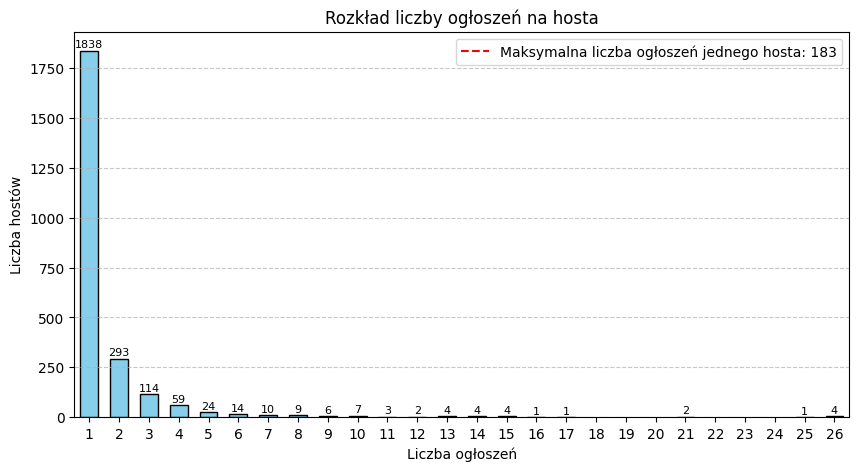

In [ ]:
print("Całkowita liczba ogłoszeń:", len(df_cleaned))
print("Liczba unikalnych hostów:", df_cleaned['host_id'].nunique())
print("Średnia liczba ogłoszeń na hosta:", len(df_cleaned) / df_cleaned['host_id'].nunique())

host_listings = df_cleaned['host_id'].value_counts()
multiple_listings = host_listings[host_listings > 1]
print("\nAnaliza hostów z wieloma ogłoszeniami:")
print(f"Liczba hostów z wieloma ogłoszeniami: {len(multiple_listings)}")
print(f"Procent hostów z wieloma ogłoszeniami: {(len(multiple_listings) / df_cleaned['host_id'].nunique() * 100):.2f}%")

max_listings_host = host_listings.iloc[0]
max_listings_host_id = host_listings.index[0]
print(f"\nNajwiększa liczba ogłoszeń dla jednego hosta: {max_listings_host}")
print(f"ID hosta z największą liczbą ogłoszeń: {max_listings_host_id}")

host_details = df_cleaned[df_cleaned['host_id'] == max_listings_host_id]
print(f"\nSzczegóły dla hosta z największą liczbą ogłoszeń:")
print(f"Średnia cena ogłoszeń: $$ {host_details['price'].mean():.2f} $$")
print(f"Najczęstszy typ pokoju: {host_details['room_type'].mode()[0]}")

counts = host_listings.value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index[:26], counts.values[:26], edgecolor='black', width=0.6, color='skyblue')
plt.title("Rozkład liczby ogłoszeń na hosta")
plt.xlabel("Liczba ogłoszeń")
plt.ylabel("Liczba hostów")
plt.axvline(x=max_listings_host, color='r', linestyle='--',
            label=f'Maksymalna liczba ogłoszeń jednego hosta: {max_listings_host}')
plt.legend(loc='upper right')

plt.xlim(0.5, 26.5)
plt.xticks(range(1, 27, 1), rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    if bar.get_x() + bar.get_width() / 2 <= 26:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=8)

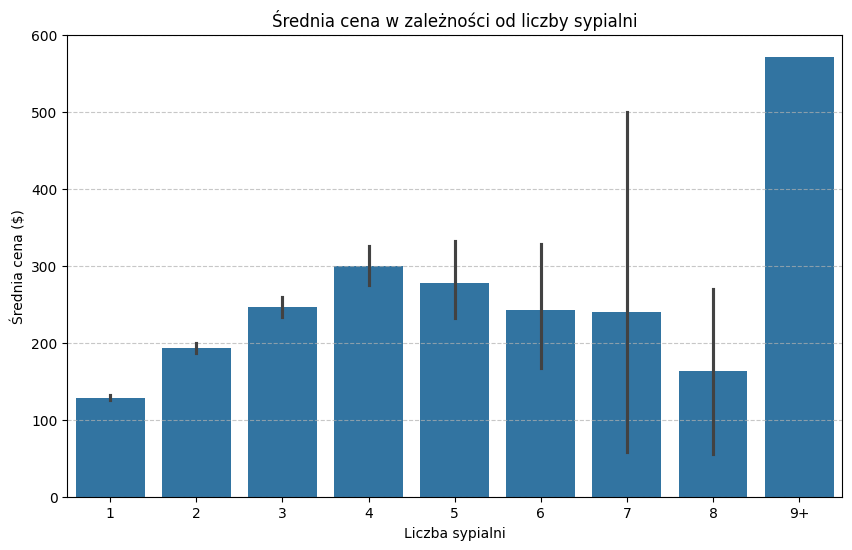

In [ ]:
df_cleaned['bedrooms'] = df_cleaned['bedrooms'].fillna(0)
df_cleaned['bedrooms_grouped'] = df_cleaned['bedrooms'].apply(lambda x: '9+' if x >= 9 else str(int(x)))

order = [str(i) for i in range(1, 9)] + ['9+']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_cleaned,
    x='bedrooms_grouped',
    y='price',
    order=order
)

plt.title("Średnia cena w zależności od liczby sypialni")
plt.xlabel("Liczba sypialni")
plt.ylabel("Średnia cena ($)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

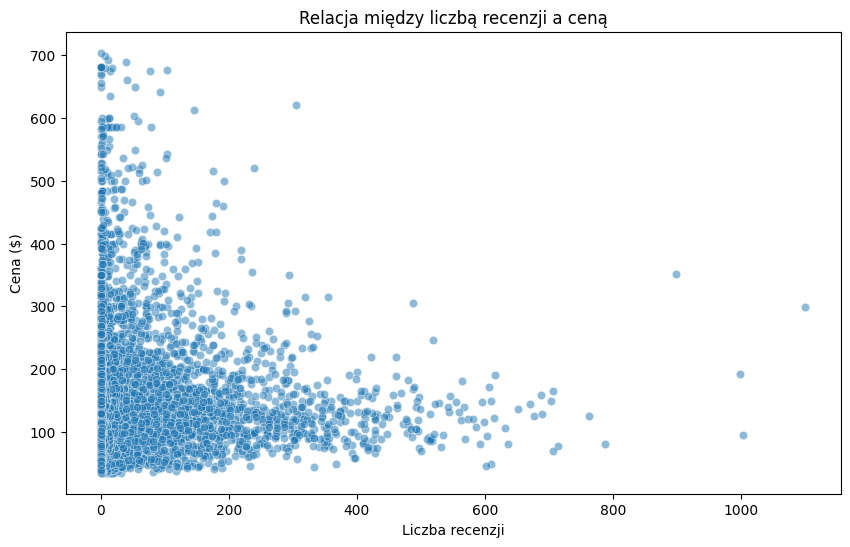

(0.0, 400.0)

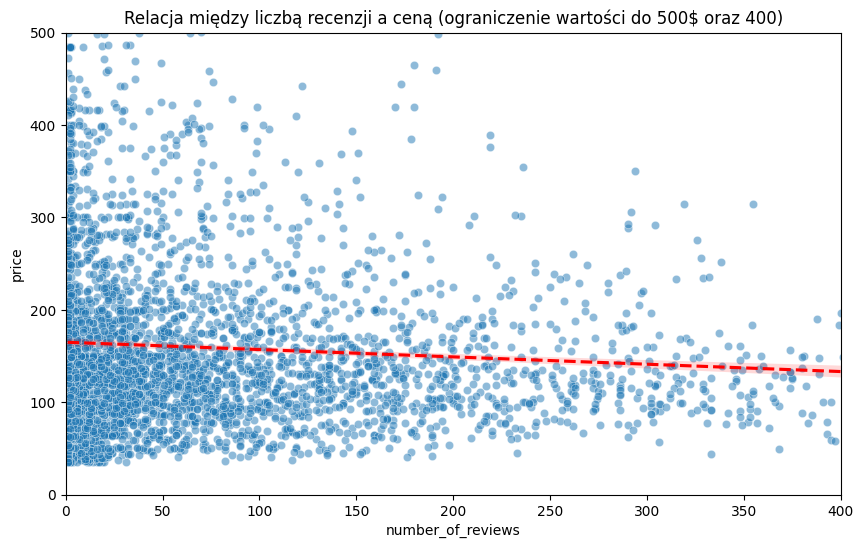

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.5)
plt.title("Relacja między liczbą recenzji a ceną")
plt.xlabel("Liczba recenzji")
plt.ylabel("Cena ($)")
plt.show()

df_with_reviews = df[df['number_of_reviews'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_with_reviews, x='number_of_reviews', y='price', alpha=0.5)
plt.title("Relacja między liczbą recenzji a ceną (ograniczenie wartości do 500$ oraz 400)")
plt.xlabel("Liczba recenzji")
plt.ylabel("Cena ($)")

sns.regplot(data=df_with_reviews, x='number_of_reviews', y='price',
            scatter=False, color='red', line_kws={'linestyle': '--'})
plt.ylim(0, 500)
plt.xlim(0, 400)

In [ ]:
'# Obliczenie korelacji Pearsona i Spearmana
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

zmienne_numeryczne = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms'
]

korelacja_pearson = df_cleaned[zmienne_numeryczne].corr(method='pearson')
korelacja_spearman = df_cleaned[zmienne_numeryczne].corr(method='spearman')

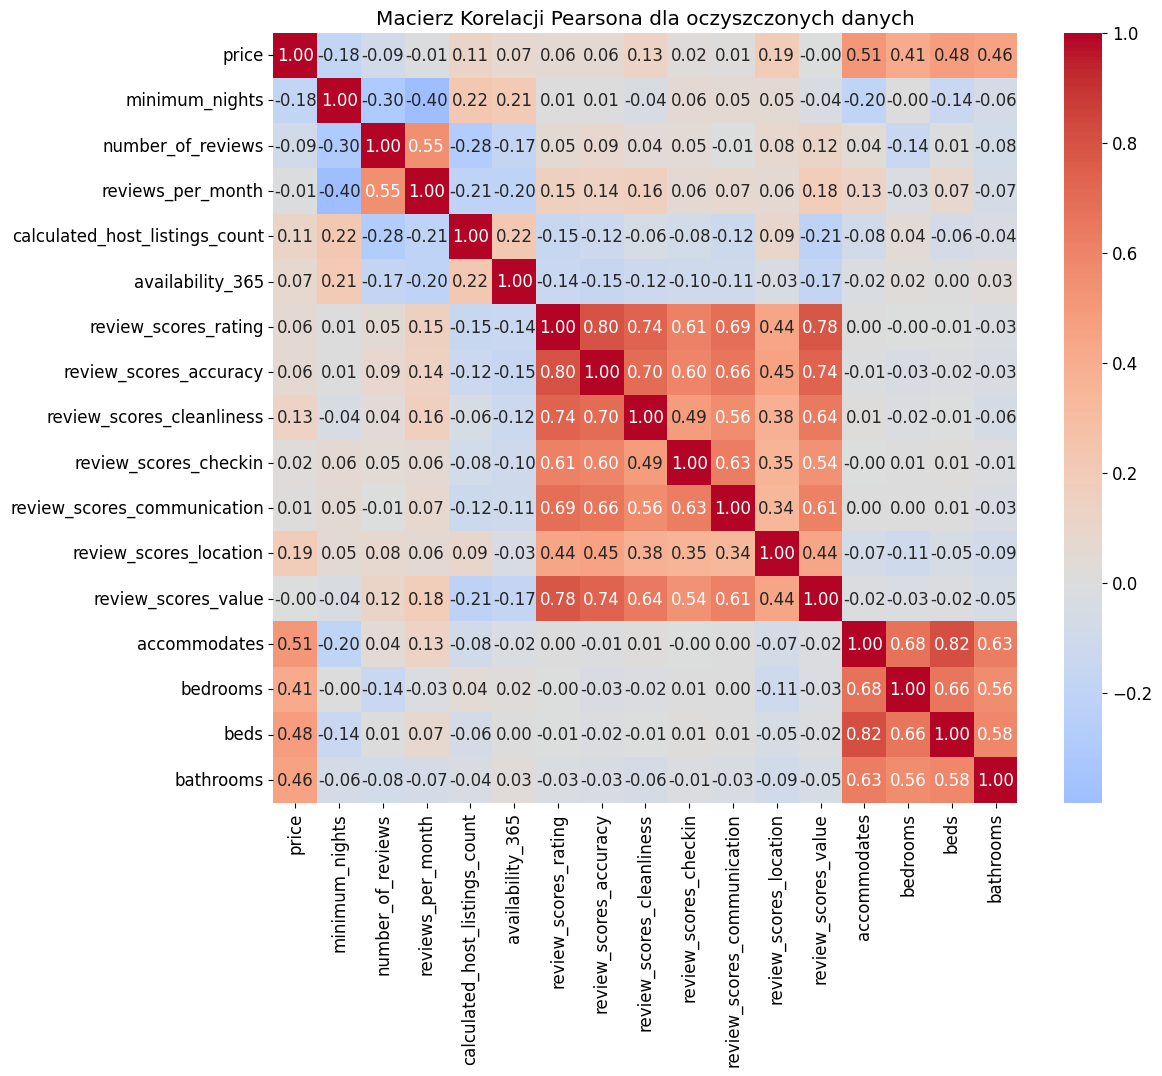

In [ ]:
# macierz Pearsona
plt.figure(figsize=(12, 10))
sns.heatmap(korelacja_pearson, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Macierz Korelacji Pearsona dla oczyszczonych danych')
plt.show()

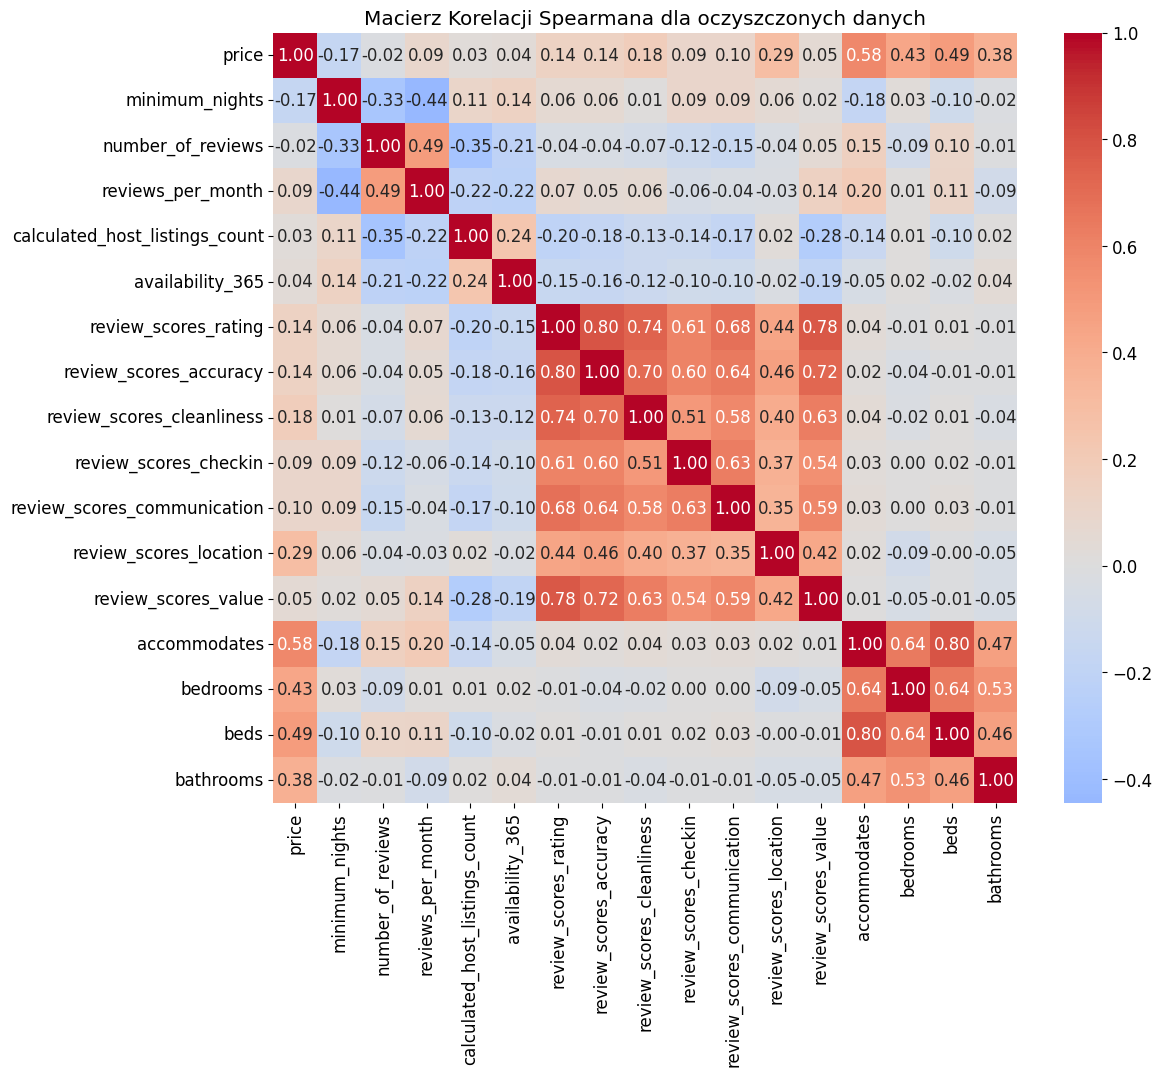

In [ ]:
# macierz Spearmana
plt.figure(figsize=(12, 10))
sns.heatmap(korelacja_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Macierz Korelacji Spearmana dla oczyszczonych danych')
plt.show()


Korelacje z ceną:
price                                           1.000000
accommodates                                    0.513043
beds                                            0.479785
bathrooms                                       0.457090
bedrooms                                        0.411333
host_total_listings_count                       0.202350
review_scores_location_zscore                   0.194891
review_scores_location_minmax                   0.194891
review_scores_location                          0.194891
availability_30                                 0.163472
host_listings_count                             0.156141
availability_60                                 0.155805
availability_90                                 0.134789
review_scores_cleanliness                       0.127273
review_scores_cleanliness_zscore                0.127273
review_scores_cleanliness_minmax                0.127273
maximum_maximum_nights                          0.122229
id          

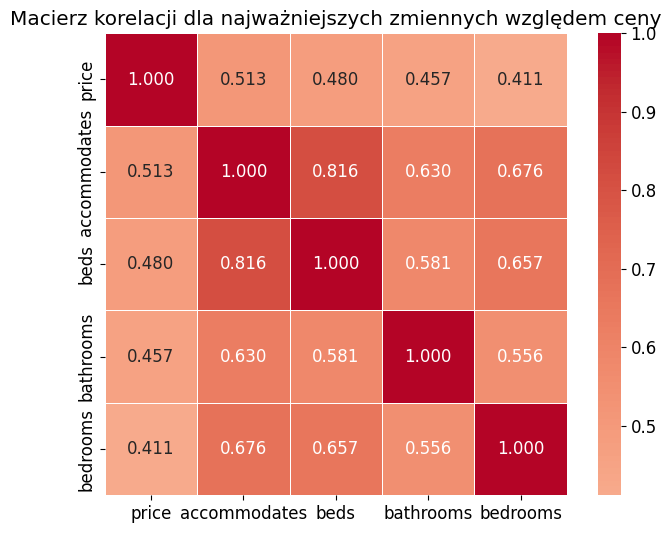

In [ ]:
# Analiza korelacji między ceną a innymi numerycznymi zmiennymi
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_cleaned[numeric_cols].corr()['price'].sort_values(ascending=False)

with pd.option_context('display.max_rows', None):
    print("\nKorelacje z ceną:")
    print(correlation_matrix)

important_vars = ['price', 'accommodates', 'beds', 'bathrooms', 'bedrooms']
correlation_matrix_important = df_cleaned[important_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_important,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.3f',
            square=True,
            linewidths=0.5)
plt.title("Macierz korelacji dla najważniejszych zmiennych względem ceny")
plt.show()

In [ ]:
print("\nNajsilniejsze korelacje z ceną:")
price_correlations = correlation_matrix_important['price'].sort_values(ascending=False)
print(price_correlations)

print("\nStatystyki opisowe dla głównych zmiennych:")
print(df_cleaned[important_vars].describe())


Najsilniejsze korelacje z ceną:
price           1.000000
accommodates    0.513043
beds            0.479785
bathrooms       0.457090
bedrooms        0.411333
Name: price, dtype: float64

Statystyki opisowe dla głównych zmiennych:
             price  accommodates         beds    bathrooms     bedrooms
count  4441.000000   4441.000000  4416.000000  4440.000000  4441.000000
mean    159.092096      3.553254     1.912138     1.317342     1.473317
std     105.344620      2.200822     1.270442     0.673471     1.028325
min      35.000000      1.000000     0.000000     0.000000     0.000000
25%      93.000000      2.000000     1.000000     1.000000     1.000000
50%     130.000000      3.000000     2.000000     1.000000     1.000000
75%     189.000000      4.000000     2.000000     1.500000     2.000000
max     704.000000     16.000000    15.000000     6.000000     9.000000


In [ ]:
# Cramer
zmienne_kategoryczne = ['room_type', 'property_type', 'neighbourhood_cleansed']
korelacje_kategoryczne = []

for i in range(len(zmienne_kategoryczne)):
    for j in range(i + 1, len(zmienne_kategoryczne)):
        tabela_kontyngencji = pd.crosstab(
            df_cleaned[zmienne_kategoryczne[i]],
            df_cleaned[zmienne_kategoryczne[j]]
        )

        # Calculate Cramer's V directly
        chi2 = stats.chi2_contingency(tabela_kontyngencji)[0]
        n = tabela_kontyngencji.sum().sum()
        phi2 = chi2 / n
        r, k = tabela_kontyngencji.shape

        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

        korelacje_kategoryczne.append({
            'Zmienna 1': zmienne_kategoryczne[i],
            'Zmienna 2': zmienne_kategoryczne[j],
            'Współczynnik V Craméra': v
        })

print("\nKorelacje między zmiennymi kategorycznymi:")
print(pd.DataFrame(korelacje_kategoryczne))


Korelacje między zmiennymi kategorycznymi:
       Zmienna 1               Zmienna 2  Współczynnik V Craméra
0      room_type           property_type                0.897265
1      room_type  neighbourhood_cleansed                0.209417
2  property_type  neighbourhood_cleansed                0.144671


In [ ]:
import statsmodels.formula.api as smf

# R kwadrat
def oblicz_r_kwadrat(zm_kat, zm_num, dane):
    model = smf.ols(f'{zm_num} ~ C({zm_kat})', data=dane).fit()
    return model.rsquared

zmienne_kategoryczne = ['room_type', 'property_type', 'neighbourhood_cleansed']
zmienne_numeryczne = [
    'price', 'accommodates', 'beds', 'bathrooms', 'bedrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month'
]

korelacje_kat_num = []
for zm_kat in zmienne_kategoryczne:
    for zm_num in zmienne_numeryczne:
        r_kwadrat = oblicz_r_kwadrat(zm_kat, zm_num, df_cleaned)
        korelacje_kat_num.append({
            'Zmienna kategoryczna': zm_kat,
            'Zmienna numeryczna': zm_num,
            'R²': r_kwadrat
        })

print("\nZależności między zmiennymi kategorycznymi a numerycznymi (R²):")
print(pd.DataFrame(korelacje_kat_num))


Zależności między zmiennymi kategorycznymi a numerycznymi (R²):
      Zmienna kategoryczna Zmienna numeryczna        R²
0                room_type              price  0.110232
1                room_type       accommodates  0.179927
2                room_type               beds  0.095400
3                room_type          bathrooms  0.016874
4                room_type           bedrooms  0.014275
5                room_type     minimum_nights  0.018596
6                room_type   availability_365  0.005512
7                room_type  number_of_reviews  0.012904
8                room_type  reviews_per_month  0.044983
9            property_type              price  0.331921
10           property_type       accommodates  0.357698
11           property_type               beds  0.249096
12           property_type          bathrooms  0.263538
13           property_type           bedrooms  0.263817
14           property_type     minimum_nights  0.106241
15           property_type   availabili

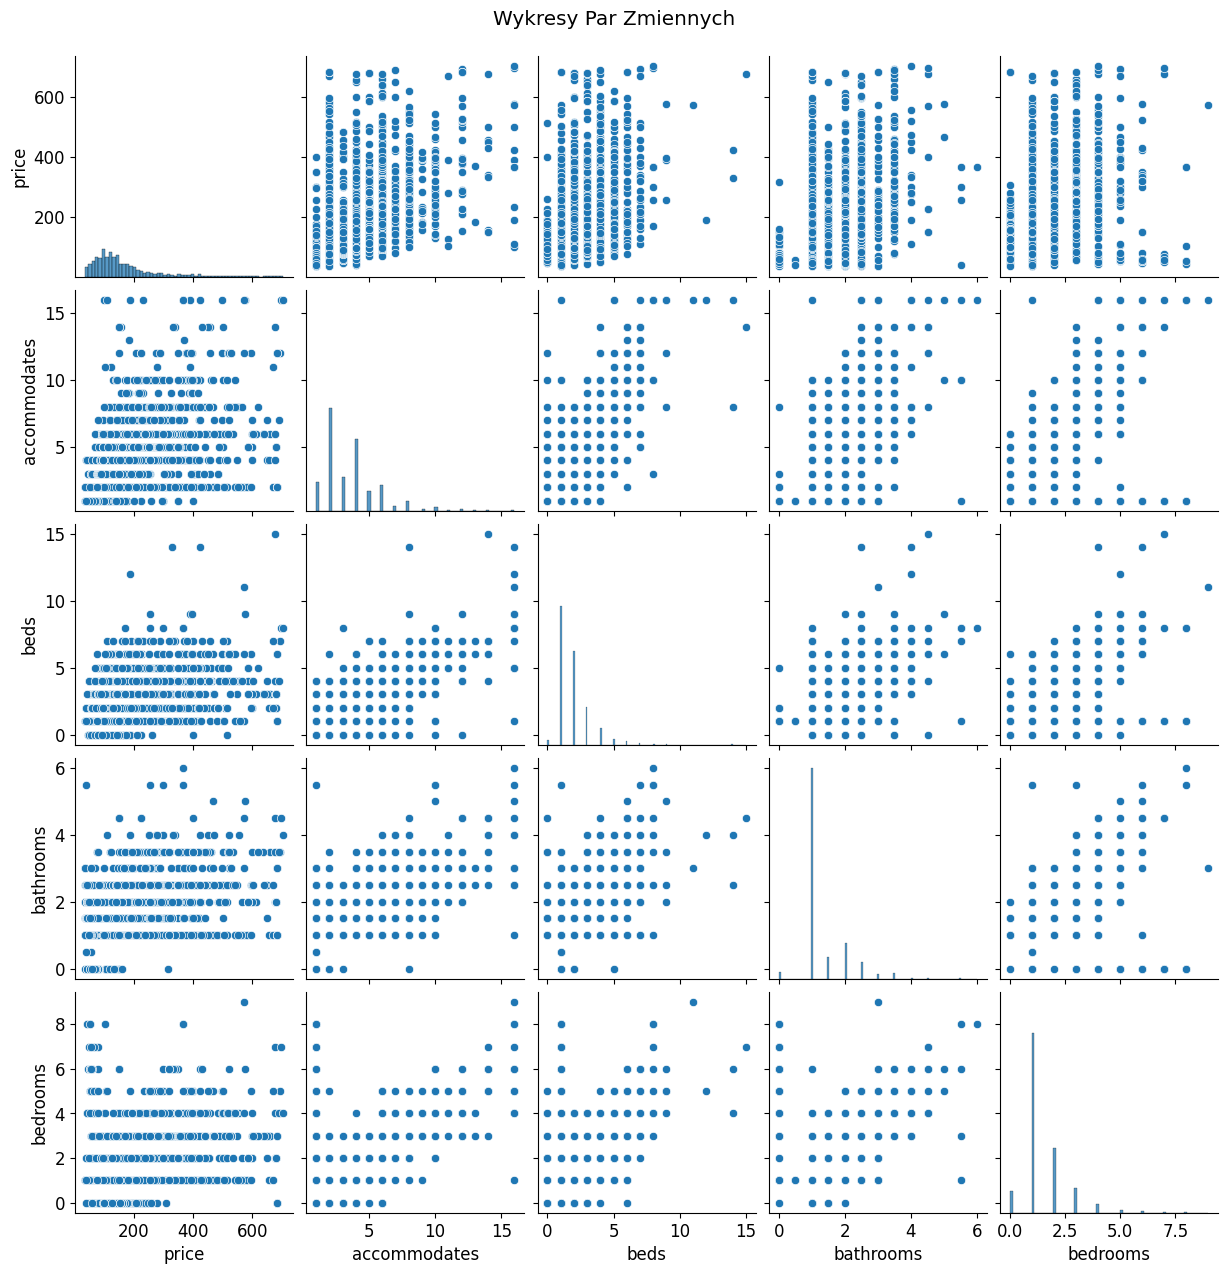

In [ ]:
# wykresy par zmiennych
important_vars = ['price', 'accommodates', 'beds', 'bathrooms', 'bedrooms']
sns.pairplot(df_cleaned[important_vars])
plt.suptitle('Wykresy Par Zmiennych', y=1.02)
plt.show()

In [ ]:
import plotly.express as px

# Analiza wzorców geograficznych
print("\nAnaliza rozkładu geograficznego ofert:")

fig = px.scatter_mapbox(df_cleaned,
                       lat='latitude',
                       lon='longitude',
                       color='price',
                       size='price',
                       hover_name='name',
                       hover_data=['room_type', 'price'],
                       color_continuous_scale='Viridis',
                       zoom=11,
                       title='Rozkład ofert Airbnb')

fig.update_layout(
    mapbox_style='carto-positron',
    margin={"r":0,"t":30,"l":0,"b":0}
)
fig.show()


Analiza rozkładu geograficznego ofert:


In [ ]:
#analiza statystyczna lokalizacji
print("\nStatystyki dla różnych dzielnic:")
location_stats = df_cleaned.groupby('neighbourhood_cleansed').agg({
    'price': ['mean', 'median', 'count'],
    'review_scores_rating': 'mean'
}).round(2)

print("\nŚrednie ceny i oceny według dzielnic:")
print(location_stats)


Statystyki dla różnych dzielnic:

Średnie ceny i oceny według dzielnic:
                                                                                                    price  \
                                                                                                     mean   
neighbourhood_cleansed                                                                                      
Brightwood Park, Crestwood, Petworth                                                               116.12   
Brookland, Brentwood, Langdon                                                                      134.00   
Capitol Hill, Lincoln Park                                                                         160.97   
Capitol View, Marshall Heights, Benning Heights                                                    127.31   
Cathedral Heights, McLean Gardens, Glover Park                                                     192.02   
Cleveland Park, Woodley Park, Massachusetts Avenue Heig

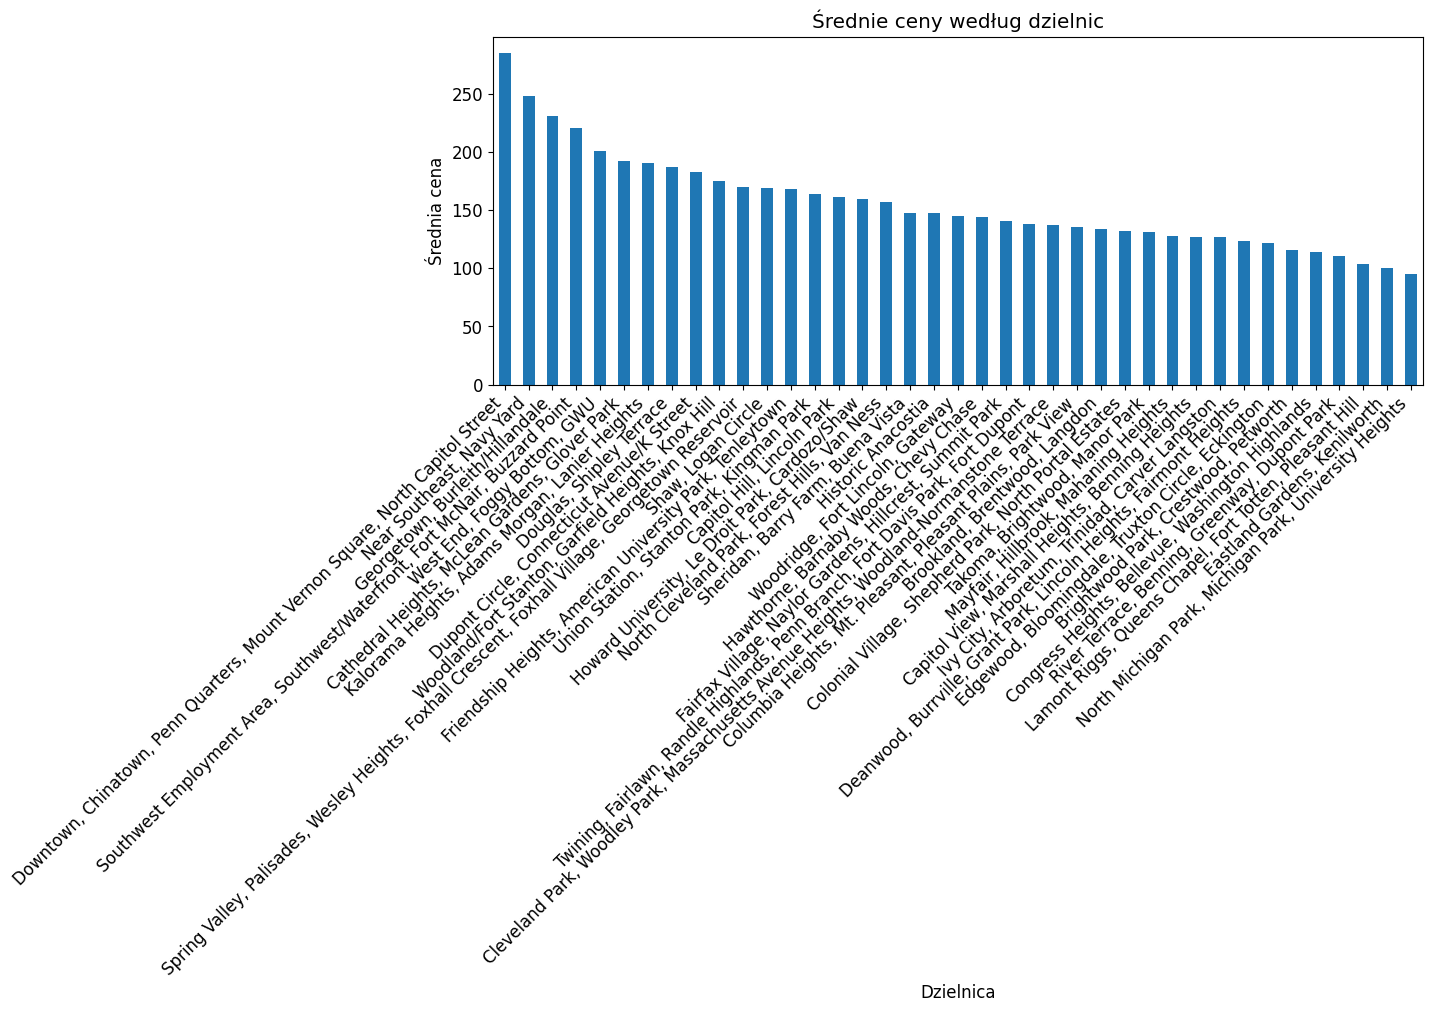

In [ ]:
plt.figure(figsize=(12, 6))
location_stats[('price', 'mean')].sort_values(ascending=False).plot(kind='bar')
plt.title('Średnie ceny według dzielnic')
plt.xlabel('Dzielnica')
plt.ylabel('Średnia cena')
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

**Analiza rynku Airbnb w Waszyngtonie - praca zaliczeniowa PRBD**

Niniejsza praca przedstawia kompleksową analizę rynku Airbnb w Waszyngtonie, wykorzystując zbiór danych zawierający początkowo 5,454 oferty opisane przez 75 zmiennych. Po oczyszczeniu danych analizowano 4,441 ofert, co zapewniło wiarygodne i reprezentatywne wyniki.

**Metodologia i jakość danych**

**Wstępna analiza braków danych:**

Całkowite braki w kolumnach:
neighbourhood_group_cleansed (100%),
calendar_updated (100%)

Znaczące braki:
host_about (35%),
neighborhood_overview (32%),
license (24%)

Braki w kluczowych zmiennych:
ceny, łazienki, łóżka (~17%)


**Oczyszczenie danych:**

Usunięcie wartości odstających w cenach (metoda IQR)

Standaryzacja formatów (daty, ceny, wartości procentowe)

Konwersja typów zmiennych


**Szczegółowa charakterystyka rynku**

1. Struktura ofert i ceny

Podział według typu zakwaterowania:

Całe mieszkania/domy: 76.18% (3,383 ofert)

Pokoje prywatne: 22.47% (998 ofert)

Pokoje hotelowe: 0.83% (37 ofert)

Pokoje współdzielone: 0.52% (23 oferty)


Analiza cenowa według typu:

Hotel room: średnio 231.50

Entire home/apt: średnio 146.00

Private room: średnio 72.00

Shared room: średnio 65.00

2. Szczegółowa analiza nieruchomości

Parametry fizyczne (średnie wartości):

Liczba miejsc noclegowych: 3.55

Liczba łóżek: 1.91

Liczba łazienek: 1.32

Liczba sypialni: 1.47

Udogodnienia:

Najczęstsze: WiFi, klimatyzacja, podstawowe wyposażenie

Wpływ na cenę: dodatkowa łazienka (+45.7% do ceny)


3. Dostępność i obłożenie

Średnia dostępność roczna: 202.5 dni

Minimalna liczba noclegów:

Średnia: 12.4 dni
Mediana: 2 dni

Maksymalna liczba noclegów: średnio 462 dni

Pogłębiona analiza zależności

1. Korelacje z ceną

Silne korelacje dodatnie:

Liczba miejsc: 0.513

Liczba łóżek: 0.480

Liczba łazienek: 0.457

Liczba sypialni: 0.411


Korelacje ujemne:

Minimum_nights: -0.178

Calculated_host_listings_count_private_rooms: -0.167

Longitude: -0.160



2. Analiza lokalizacyjna

Wpływ dzielnicy (R² = 0.161)

Najlepiej oceniane lokalizacje:

Capitol Hill, Lincoln Park

Dupont Circle, Connecticut Avenue/K Street

Columbia Heights, Mt. Pleasant



**Szczegółowa analiza hostów**
1. Struktura rynku

Liczba unikalnych hostów: 2,406

Średnio 1.85 oferty na hosta

23.61% hostów z wieloma ofertami

2. Profesjonalizacja

Top hosci:

Największy host: 183 oferty

Średnia cena u największego hosta: $167.29

Dominujący typ: Entire home/apt



3. Charakterystyka operacyjna

Czas odpowiedzi:

77% odpowiada w ciągu godziny

12% w ciągu kilku godzin


Wskaźnik akceptacji: średnio 72-96%

**Szczegółowa analiza ocen i recenzji**

1. Rozkład ocen

Ogólna: 4.76/5

Szczegółowe kategorie:

Zameldowanie: 4.88/5

Komunikacja: 4.87/5

Dokładność: 4.82/5

Czystość: 4.79/5

Lokalizacja: 4.75/5

Stosunek jakości do ceny: 4.72/5



2. Analiza recenzji

Średnia liczba recenzji: 69.4

Mediana: 24

Średnia miesięczna: 2.31

Recenzje w ostatnich 12 miesiącach: średnio 17.16

**Trendy i wzorce**
1. Wzorce cenowe

Wyższe ceny w weekendy i sezony turystyczne

Premium za dodatkowe udogodnienia

Zróżnicowanie według lokalizacji

2. Wzorce dostępności

Większa dostępność w okresach pozasezonowych

Krótsze minimalne pobyty w centrum miasta

Dłuższe minimalne pobyty w obszarach podmiejskich

**Kluczowe wnioski i rekomendacje**
1. Dla inwestorów

Fokus na nieruchomości 2-4 osobowe z dodatkową łazienką

Priorytet dla popularnych lokalizacji

Rozważenie modelu multiple listings

2. Dla hostów

Automatyzacja i standaryzacja procesów

Nacisk na szybką komunikację

Dynamiczne zarządzanie cenami

3. Dla gości

Wcześniejsze planowanie w popularnych lokalizacjach

Rozważenie dłuższych pobytów

Zwracanie uwagi na oceny czystości i komunikacji

**Podsumowanie**

Analiza ujawnia dojrzały, profesjonalizujący się rynek z wyraźną segmentacją i wysokimi standardami. Sukces zależy od kombinacji czynników lokalizacyjnych, standardu nieruchomości i efektywności operacyjnej. Przyszły rozwój będzie ukierunkowany na automatyzację i ekspansję w nowych lokalizacjach.